In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns',None)

In [2]:
df = pd.read_excel("Amazon.xlsx")
df.head()

,Order ID,Order Date,Ship Date,EmailID,Geography,Category,Product Name,Sales,Quantity,Profit,Shipping Days
0,CA-2013-138688,2013-06-13,2013-06-17,DarrinVanHuff@gmail.com,"United States,Los Angeles,California",Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,6.8714,4
1,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,14.1694,5
2,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Art,Newell 322,7.280,4,1.9656,5
3,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Phones,Mitel 5320 IP Phone VoIP phone,907.152,4,90.7152,5
4,CA-2011-115812,2011-06-09,2011-06-14,BrosinaHoffman@gmail.com,"United States,Los Angeles,California",Binders,DXL Angle-View Binders with Locking Rings by S...,18.504,3,5.7825,5


In [3]:
df.shape

(3203, 11)

In [4]:
df.columns

Index(['Order ID', 'Order Date', 'Ship Date', 'EmailID', 'Geography',
       'Category', 'Product Name', 'Sales', 'Quantity', 'Profit',
       'Shipping Days'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       3203 non-null   object        
 1   Order Date     3203 non-null   datetime64[ns]
 2   Ship Date      3203 non-null   datetime64[ns]
 3   EmailID        3203 non-null   object        
 4   Geography      3203 non-null   object        
 5   Category       3203 non-null   object        
 6   Product Name   3203 non-null   object        
 7   Sales          3203 non-null   float64       
 8   Quantity       3203 non-null   int64         
 9   Profit         3203 non-null   float64       
 10  Shipping Days  3203 non-null   int64         
dtypes: datetime64[ns](2), float64(2), int64(2), object(5)
memory usage: 275.4+ KB


In [7]:
df.describe()

,Order Date,Ship Date,Sales,Quantity,Profit,Shipping Days
count,3203,3203,3203.000000,3203.000000,3203.000000,3203.000000
mean,2013-05-10 03:06:07.530440192,2013-05-14 01:25:25.195129600,226.493233,3.828910,33.849032,3.930066
min,2011-01-07 00:00:00,2011-01-09 00:00:00,0.990000,1.000000,-3399.980000,0.000000
25%,2012-05-22 00:00:00,2012-05-26 00:00:00,19.440000,2.000000,3.852000,3.000000
50%,2013-07-22 00:00:00,2013-07-25 00:00:00,60.840000,3.000000,11.166400,4.000000
75%,2014-05-23 00:00:00,2014-05-27 00:00:00,215.809000,5.000000,33.000400,5.000000
max,2014-12-31 00:00:00,2015-01-06 00:00:00,13999.960000,14.000000,6719.980800,7.000000
std,NaN,NaN,524.876877,2.260947,174.109081,1.806914


In [8]:
df.isnull().sum()

Order ID         0
Order Date       0
Ship Date        0
EmailID          0
Geography        0
Category         0
Product Name     0
Sales            0
Quantity         0
Profit           0
Shipping Days    0
dtype: int64

In [9]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
3198    False
3199    False
3200    False
3201    False
3202    False
Length: 3203, dtype: bool

In [10]:
df.duplicated().sum()

0

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       3203 non-null   object        
 1   Order Date     3203 non-null   datetime64[ns]
 2   Ship Date      3203 non-null   datetime64[ns]
 3   EmailID        3203 non-null   object        
 4   Geography      3203 non-null   object        
 5   Category       3203 non-null   object        
 6   Product Name   3203 non-null   object        
 7   Sales          3203 non-null   float64       
 8   Quantity       3203 non-null   int64         
 9   Profit         3203 non-null   float64       
 10  Shipping Days  3203 non-null   int64         
dtypes: datetime64[ns](2), float64(2), int64(2), object(5)
memory usage: 275.4+ KB


In [21]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    format='%d-%m-%Y'
)

df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],
    format='%d-%m-%Y'
)

In [23]:
df.head(1)

,Order ID,Order Date,Ship Date,EmailID,Geography,Category,Product Name,Sales,Quantity,Profit,Shipping Days
0,CA-2013-138688,2013-06-13,2013-06-17,DarrinVanHuff@gmail.com,"United States,Los Angeles,California",Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,6.8714,4


In [25]:
df['Sales'].sum()

725457.8245

In [27]:
df['Profit'].sum()

108418.4489

In [29]:
(df['Profit'].sum()/df['Sales'].sum()) * 100

14.944831420727203

In [31]:
category_sales = (
                df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
                )

category_sales

Category
Chairs         101781.3280
Phones          98684.3520
Tables          84754.5620
Storage         70532.8520
Accessories     61114.1160
Binders         55961.1130
Copiers         49749.2420
Machines        42444.1220
Bookcases       36004.1235
Appliances      30236.3360
Furnishings     30072.7300
Paper           26663.7180
Supplies        18127.1220
Art              9212.0660
Labels           5078.7260
Envelopes        4118.1000
Fasteners         923.2160
Name: Sales, dtype: float64

In [33]:
df['Sales'].describe()

count     3203.000000
mean       226.493233
std        524.876877
min          0.990000
25%         19.440000
50%         60.840000
75%        215.809000
max      13999.960000
Name: Sales, dtype: float64

In [35]:
df['Profit'].describe()

count    3203.000000
mean       33.849032
std       174.109081
min     -3399.980000
25%         3.852000
50%        11.166400
75%        33.000400
max      6719.980800
Name: Profit, dtype: float64

In [37]:
df.groupby('Category')['Sales'].sum()

Category
Accessories     61114.1160
Appliances      30236.3360
Art              9212.0660
Binders         55961.1130
Bookcases       36004.1235
Chairs         101781.3280
Copiers         49749.2420
Envelopes        4118.1000
Fasteners         923.2160
Furnishings     30072.7300
Labels           5078.7260
Machines        42444.1220
Paper           26663.7180
Phones          98684.3520
Storage         70532.8520
Supplies        18127.1220
Tables          84754.5620
Name: Sales, dtype: float64

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       3203 non-null   object        
 1   Order Date     3203 non-null   datetime64[ns]
 2   Ship Date      3203 non-null   datetime64[ns]
 3   EmailID        3203 non-null   object        
 4   Geography      3203 non-null   object        
 5   Category       3203 non-null   object        
 6   Product Name   3203 non-null   object        
 7   Sales          3203 non-null   float64       
 8   Quantity       3203 non-null   int64         
 9   Profit         3203 non-null   float64       
 10  Shipping Days  3203 non-null   int64         
dtypes: datetime64[ns](2), float64(2), int64(2), object(5)
memory usage: 275.4+ KB


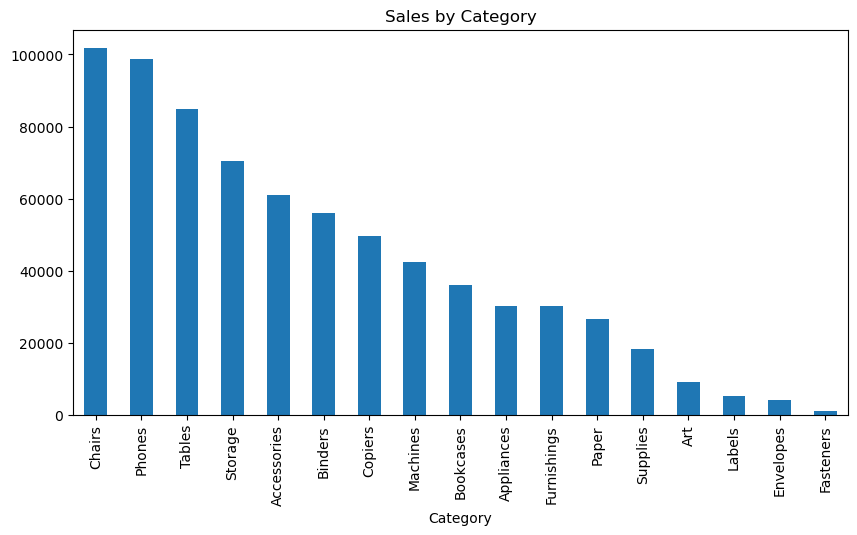

In [41]:
category_sales.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Sales by Category')
plt.show()

In [43]:
df['Month'] = (
    df['Order Date']
    .dt.to_period('M')
)

In [45]:
df.head(1)

,Order ID,Order Date,Ship Date,EmailID,Geography,Category,Product Name,Sales,Quantity,Profit,Shipping Days,Month
0,CA-2013-138688,2013-06-13,2013-06-17,DarrinVanHuff@gmail.com,"United States,Los Angeles,California",Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,6.8714,4,2013-06


In [47]:
monthly_sales = (
    df.groupby('Month')['Sales'].sum()
)

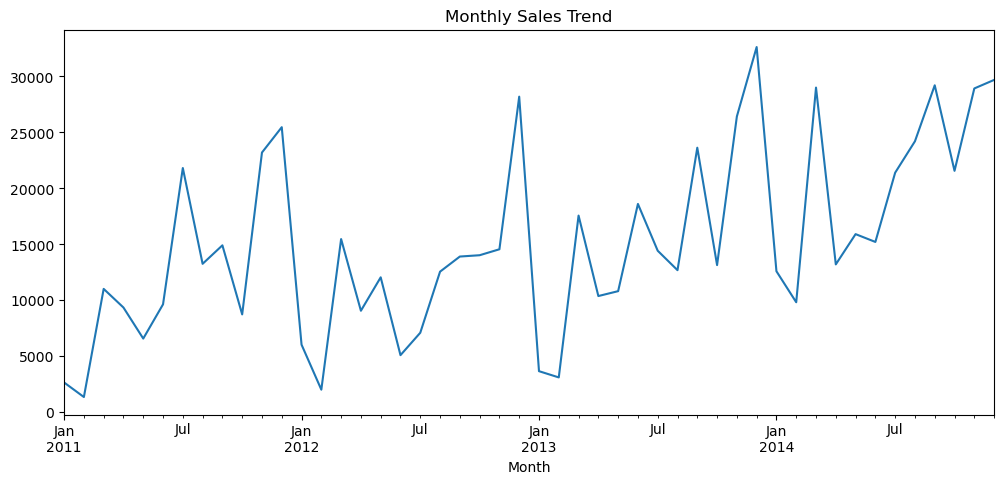

In [49]:
monthly_sales.plot(
    figsize=(12,5)
)

plt.title('Monthly Sales Trend')
plt.show()

In [50]:
category_profit = (
    df.groupby('Category')['Profit'].sum()
      .sort_values(ascending=False)
)

category_profit

Category
Copiers        19327.2351
Accessories    16484.5983
Binders        16096.8016
Paper          12119.2364
Phones          9110.7426
Storage         8645.3222
Appliances      8261.2699
Furnishings     7641.2704
Chairs          4027.5843
Art             2374.0970
Labels          2303.1223
Envelopes       1908.7624
Tables          1482.6073
Supplies         626.0465
Fasteners        275.1907
Machines        -618.9264
Bookcases      -1646.5117
Name: Profit, dtype: float64

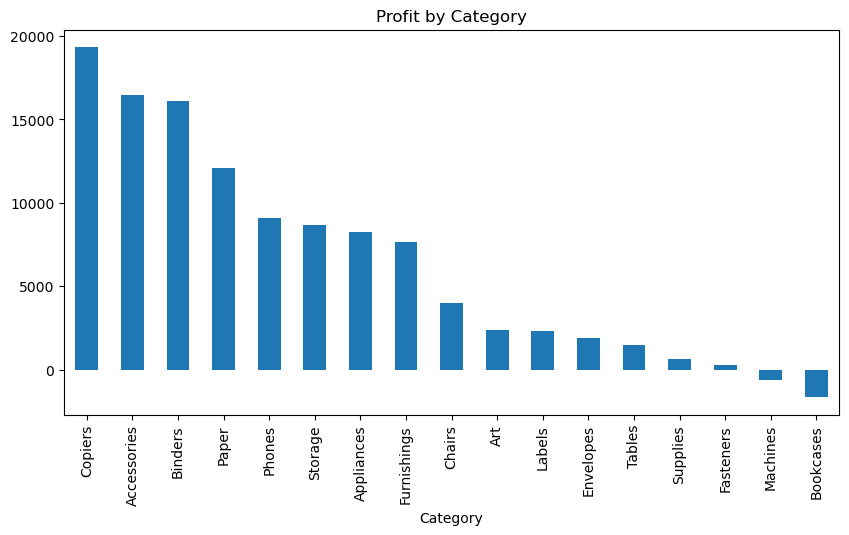

In [51]:
category_profit.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Profit by Category')
plt.show()

In [53]:
top_products = (
    df.groupby('Product Name')['Profit']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          6719.9808
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    3050.3760
Canon PC1060 Personal Laser Copier                                             2267.9676
Hewlett Packard LaserJet 3310 Copier                                           2183.9636
LogitechÂ Z-906 Speaker sys - home theater - 5.1-CH                            1715.9480
Plantronics Savi W720 Multi-Device Wireless Headset System                     1670.9220
Ibico EPK-21 Electric Binding System                                           1644.2913
Canon PC940 Copier                                                             1480.4671
LogitechÂ P710e Mobile Speakerphone                                            1418.7699
Canon Image Class D660 Copier                                                  1379.9770
Name: Profit, dtype: float64

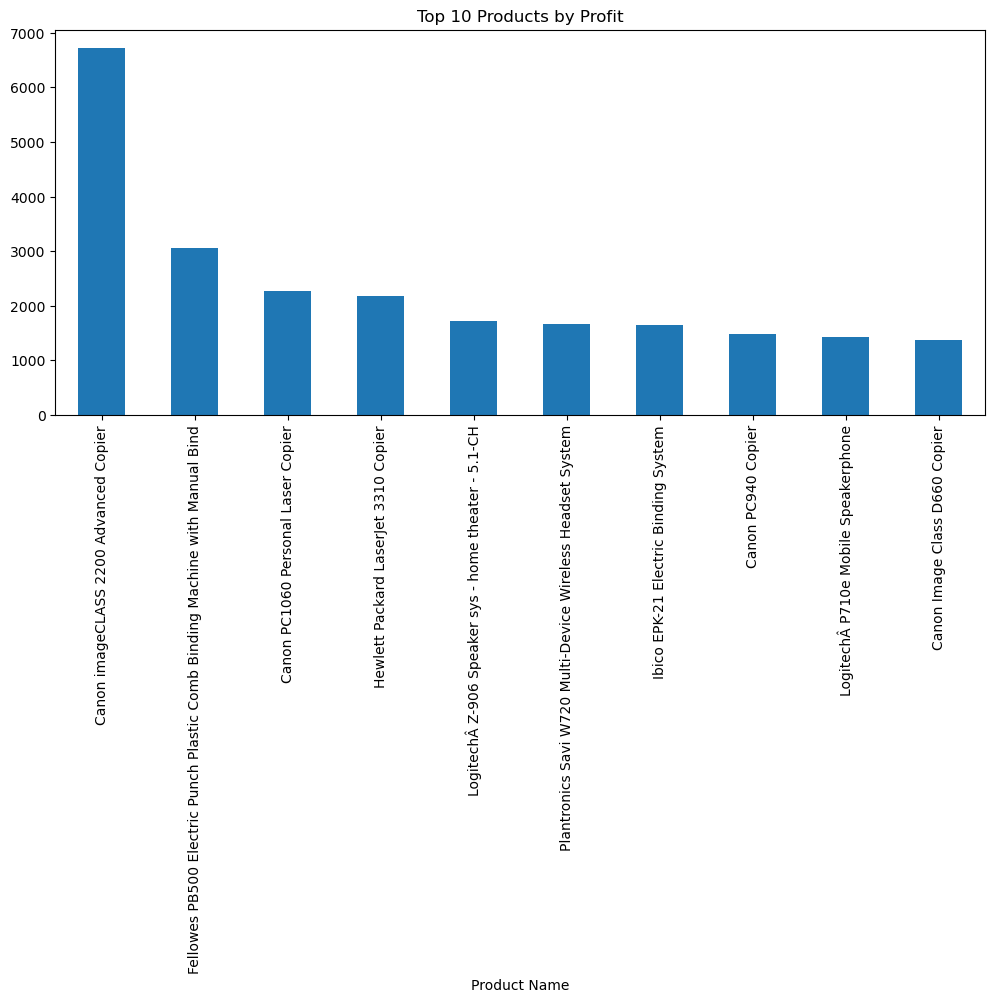

In [55]:
top_products.plot(
    kind='bar',
    figsize=(12,5)
)

plt.title('Top 10 Products by Profit')
plt.show()

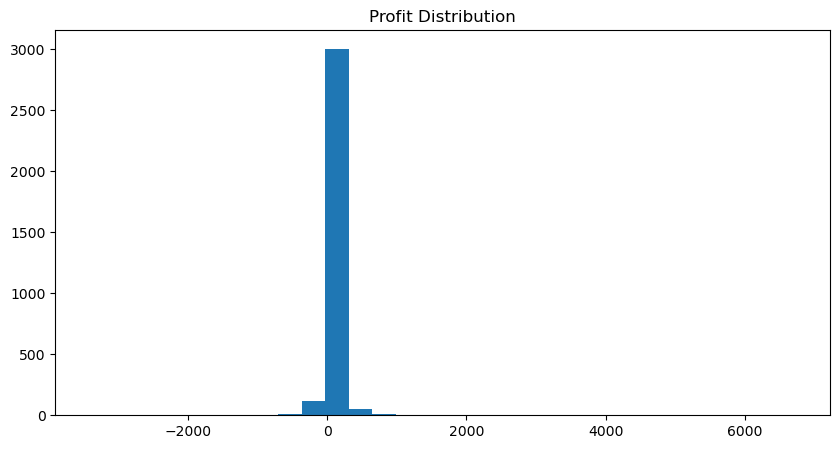

In [56]:
plt.figure(figsize=(10,5))

plt.hist(df['Profit'], bins=30)

plt.title('Profit Distribution')

plt.show()

In [59]:
df['State'] = (
    df['Geography']
    .str.split(',')
    .str[-1]
    .str.strip()
)

In [60]:
df[['Geography','State']].head()

,Geography,State
0,"United States,Los Angeles,California",California
1,"United States,Los Angeles,California",California
2,"United States,Los Angeles,California",California
3,"United States,Los Angeles,California",California
4,"United States,Los Angeles,California",California


In [61]:
state_profit = (
    df.groupby('State')['Profit']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

state_profit

State
California    76381.3871
Washington    33402.6517
Nevada         3316.7659
Utah           2546.5335
Montana        1833.3285
New Mexico     1157.1161
Idaho           826.7231
Wyoming         100.1960
Oregon        -1190.4705
Arizona       -3427.9246
Name: Profit, dtype: float64

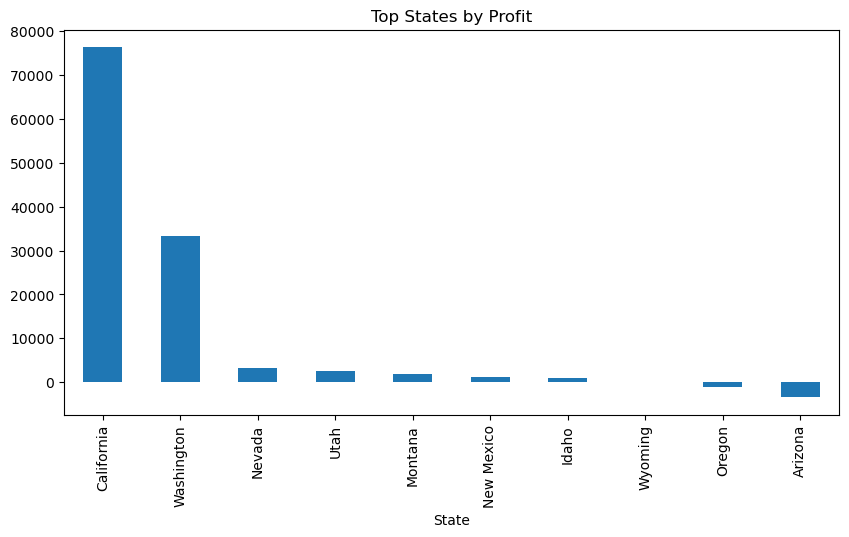

In [63]:
state_profit.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top States by Profit')
plt.show()

In [64]:
top_customers = (
    df.groupby('EmailID')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

EmailID
RaymondBuch@gmail.com      14345.2760
KenLonsdale@gmail.com       8472.3940
EdwardHooks@gmail.com       7447.7700
JaneWaco@gmail.com          7391.5300
KarenFerguson@gmail.com     7182.7660
NickCrebassa@gmail.com      6734.2330
ClayLudtke@gmail.com        6069.6440
YanaSorensen@gmail.com      5754.1720
NoraPreis@gmail.com         5564.5985
WilliamBrown@gmail.com      5523.0540
Name: Sales, dtype: float64

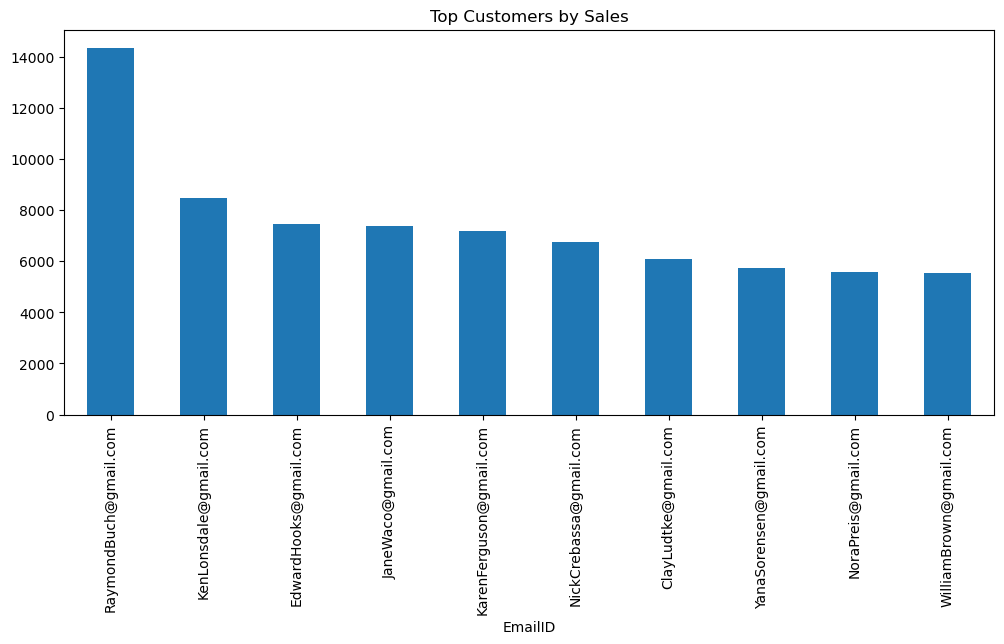

In [66]:
top_customers.plot(
    kind='bar',
    figsize=(12,5)
)

plt.title('Top Customers by Sales')
plt.show()

In [79]:
df.head(1)

,Order ID,Order Date,Ship Date,EmailID,Geography,Category,Product Name,Sales,Quantity,Profit,Shipping Days,Month,State
0,CA-2013-138688,2013-06-13,2013-06-17,DarrinVanHuff@gmail.com,"United States,Los Angeles,California",Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,6.8714,4,2013-06,California


## Customer Segmentation (RFM Analysis)

### Recency Frequency Monetary

In [81]:
latest_date = df['Order Date'].max()

latest_date

Timestamp('2014-12-31 00:00:00')

In [83]:
rfm = df.groupby('EmailID').agg({

    'Order Date': lambda x: (latest_date - x.max()).days,

    'Order ID': 'nunique',

    'Sales': 'sum'

})

In [85]:
rfm.columns = [

    'Recency',
    'Frequency',
    'Monetary'

]

rfm.head()

,Recency,Frequency,Monetary
EmailID,,,
AaronBergman@gmail.com,1395,1,309.592
AaronHawkins@gmail.com,734,3,1328.124
AaronSmayling@gmail.com,88,3,737.028
AdamBellavance@gmail.com,54,3,2693.918
AdamHart@gmail.com,259,3,463.770


In [87]:
rfm['Customer_Type'] = np.where(

    rfm['Monetary'] > rfm['Monetary'].median(),

    'High Value',

    'Low Value'

)

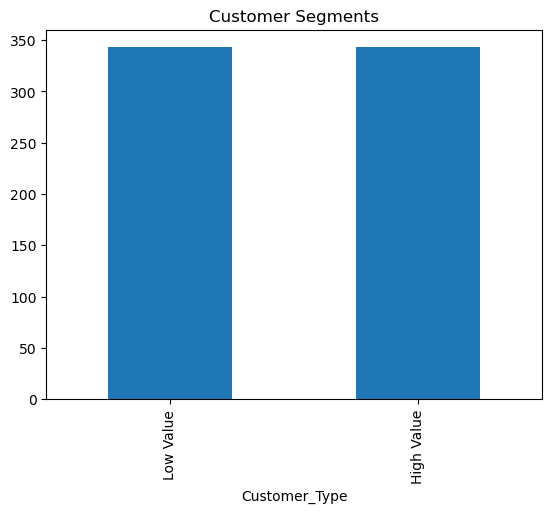

In [89]:
rfm['Customer_Type'].value_counts().plot(
    kind='bar'
)

plt.title('Customer Segments')

plt.show()

In [95]:
rfm.head(10)

,Recency,Frequency,Monetary,Customer_Type
EmailID,,,,
AaronBergman@gmail.com,1395,1,309.592,Low Value
AaronHawkins@gmail.com,734,3,1328.124,High Value
AaronSmayling@gmail.com,88,3,737.028,High Value
AdamBellavance@gmail.com,54,3,2693.918,High Value
AdamHart@gmail.com,259,3,463.770,Low Value
AdamShillingsburg@gmail.com,1103,1,13.970,Low Value
AdrianBarton@gmail.com,102,3,1330.177,High Value
AdrianHane@gmail.com,266,3,1309.864,High Value
AdrianShami@gmail.com,412,1,4.180,Low Value


In [97]:
rfm['Customer_Type'] = np.where(
    rfm['Monetary'] > rfm['Monetary'].median(),
    'High Value',
    'Low Value'
)

In [99]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    4,
    labels=[4,3,2,1]
)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1,2,3,4]
)

In [101]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(int)
    +
    rfm['F_Score'].astype(int)
    +
    rfm['M_Score'].astype(int)
)

In [103]:
rfm['Segment'] = np.where(
    rfm['RFM_Score'] >= 9,
    'Champions',
    np.where(
        rfm['RFM_Score'] >= 6,
        'Loyal Customers',
        'At Risk'
    )
)

In [105]:
rfm['Segment'].value_counts()

Segment
Champions          266
Loyal Customers    255
At Risk            165
Name: count, dtype: int64

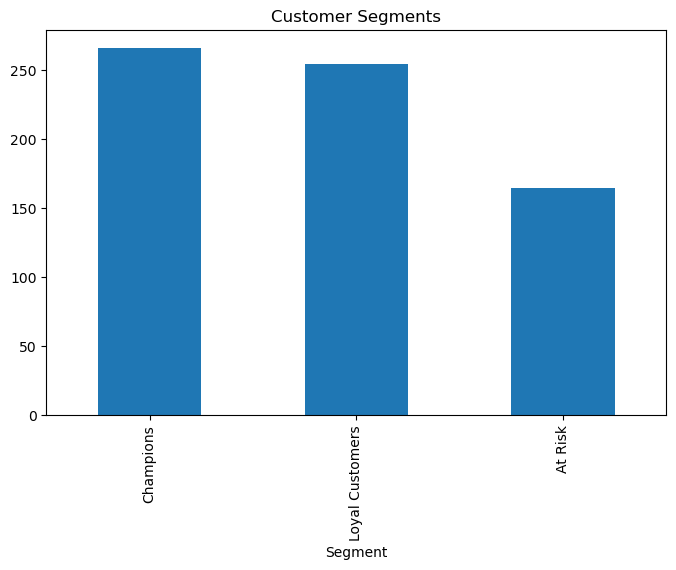

In [107]:
rfm['Segment'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Customer Segments')
plt.show()